In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


from torchvision.utils import make_grid
import numpy as np
import ssl

## train

In [2]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng: {device}") # phải là: Đang sử dụng: cuda


Đang sử dụng: cuda


In [3]:
# Định nghĩa các transform để tiền xử lý dữ liệu
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [4]:
# Đường dẫn đến dữ liệu
data_dir = "data/cic_ddos_2019_images"
train_dir = f"{data_dir}/train"
valid_dir = f"{data_dir}/valid"
test_dir = f"{data_dir}/test"

In [5]:
# Load dữ liệu
train_data = datasets.ImageFolder(root=train_dir, transform=transform)
valid_data = datasets.ImageFolder(root=valid_dir, transform=transform)
test_data = datasets.ImageFolder(root=test_dir, transform=transform)

# DataLoader
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [ ]:
# Sử dụng khi thuê GPU trên máy ảo để tải base model
ssl._create_default_https_context = ssl._create_unverified_context

In [6]:
# Load mô hình AlexNet và chỉnh sửa output
model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, len(train_data.classes))
model = model.to(device)

In [7]:
print(torch.cuda.is_available())
print(next(model.parameters()).device)

True
cuda:0


In [8]:
# Định nghĩa loss function và optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
print(torch.cuda.is_available())  # Kiểm tra GPU có khả dụng không
print(torch.cuda.device_count())  # Kiểm tra số lượng GPU
print(torch.cuda.get_device_name(0))  # Xem tên GPU
print(torch.cuda.current_device())  # GPU đang sử dụng

True
1
NVIDIA GeForce GTX 1650
0


In [9]:
print(torch.version.cuda)  # Phiên bản CUDA mà PyTorch hỗ trợ
print(torch.backends.cudnn.enabled)  # Kiểm tra CUDNN có hoạt động không

11.8
True


In [10]:
# Lưu lại lịch sử loss và accuracy
train_loss_history = []
valid_loss_history = []
train_acc_history = []
valid_acc_history = []


# Huấn luyện mô hình
epochs = 20
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    
    # Đánh giá trên tập validation
    model.eval()
    valid_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            valid_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    valid_loss /= len(valid_loader)
    valid_acc = 100 * correct / total
    valid_loss_history.append(valid_loss)
    valid_acc_history.append(valid_acc)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.2f}%")



Epoch 1/20, Train Loss: 0.0803, Train Acc: 97.64%, Valid Loss: 0.0217, Valid Acc: 99.39%
Epoch 2/20, Train Loss: 0.0082, Train Acc: 99.73%, Valid Loss: 0.0049, Valid Acc: 99.88%
Epoch 3/20, Train Loss: 0.0093, Train Acc: 99.76%, Valid Loss: 0.0106, Valid Acc: 99.73%
Epoch 4/20, Train Loss: 0.0063, Train Acc: 99.90%, Valid Loss: 0.0041, Valid Acc: 99.97%


KeyboardInterrupt: 

In [55]:
# Lưu mô hình
torch.save(model.state_dict(), "models/cic-ddos2019/alexnet.pth")

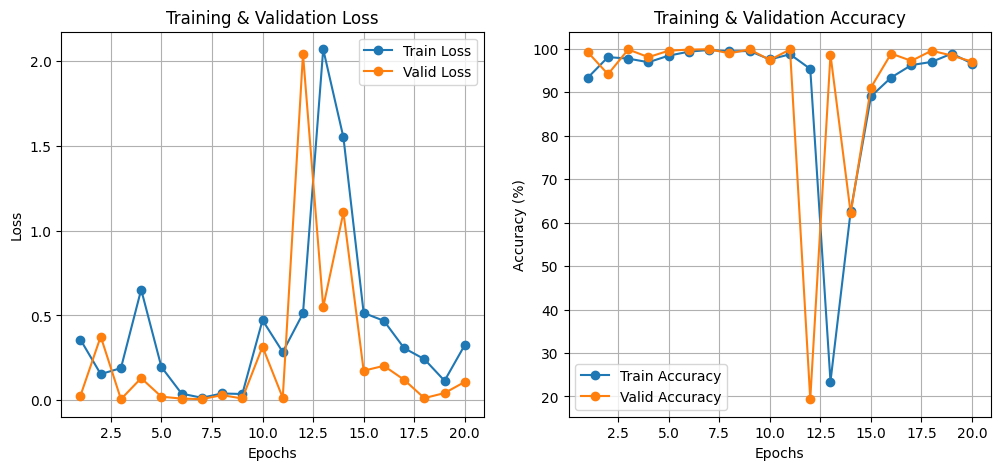

In [56]:
# Vẽ biểu đồ loss và accuracy
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_loss_history, label="Train Loss", marker="o")
plt.plot(range(1, epochs+1), valid_loss_history, label="Valid Loss", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_acc_history, label="Train Accuracy", marker="o")
plt.plot(range(1, epochs+1), valid_acc_history, label="Valid Accuracy", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid()

In [57]:
# Đánh giá trên tập test
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f"Test Accuracy: {100*correct/total:.2f}%")


Test Accuracy: 97.14%
